# Introduction to Single-Cell RNA-seq Analysis

In this assignment you will perform a complete single-cell RNA-seq analysis pipeline:
quality control, cell filtering, dimensionality reduction, clustering, manual annotation,
and differential expression testing.

## Resources
- 📖 **Scanpy tutorials** (easy-to-follow guide): https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html
- 📖 **Single-Cell Best Practices** (more verbose explanation of each step): https://www.sc-best-practices.org/
- 📖 **Scanpy documentation** (API): https://scanpy.readthedocs.io/

## Submission

At the end of the assignment you will export two files:

1. `obs.tsv` — the cell-level metadata table (tab-separated), which **must** contain a column called `manual_celltype_labels`.
2. A CSV file with your differential expression results.
3. Your AnnData object saved as `<filename>_qc.h5ad` (not committed — too large for GitHub).

Only `obs.tsv` and the DE results CSV should be committed to the repository.

> **Note:** Do **not** commit `.h5ad`, `.h5`, or other large binary files. They are excluded by `.gitignore`.

---

## 0 — Imports

Import the libraries you will need. At minimum you will need `scanpy`, `anndata`, `pandas`, `numpy`, and `matplotlib`.

> **Hint:** It is good practice to set `sc.settings.verbosity` and `sc.settings.figdir` at the top of your script.

## 1 — Load Data

Load the test AnnData object provided in the `data/` folder. Note, for tutorial purposes, a downsampled anndata object is used in this notebook.
The dataset comes from a BD rhapsody experiment, where PBMC from a healthy donor were sequenced. For verification purposes, the annotation is provided in the dataset.

> **Hint:** Use `sc.read_h5ad()` or `anndata.read_h5ad()`.  
> See: https://anndata.readthedocs.io/en/latest/generated/anndata.read_h5ad.html

After loading, inspect the object — check `.obs`, `.var`, `.X`, and `.uns` to understand the data.

## 2 — Quality Control (QC)

Calculate and visualize standard QC metrics:

- **Total counts** per cell (`total_counts`)
- **Number of detected genes** per cell (`n_genes_by_counts`)
- **Mitochondrial content** — percentage of counts from mitochondrial genes (`pct_counts_mt`)  
  Mitochondrial gene names typically start with `"MT-"` (human) or `"mt-"` (mouse).
- **Ribosomal content** — percentage of counts from ribosomal protein genes (`pct_counts_ribo`)  
  Ribosomal gene names typically start with `"RPS"` or `"RPL"` (human).

> **Hint:** 
> See: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html

Plot the distributions using `sc.pl.violin()` or a scatter plot.  
Refer to the [Best Practices quality control chapter](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html) for guidance on thresholds.

### 2.1. QC metrics
Find out which the most popular quality control metrics are and make a relevant plot

AnnData object with n_obs × n_vars = 1000 × 1176
    obs: 'celltype_semi_manual', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## 3 — Cell & Gene Filtering

Based on your QC plots, define thresholds to remove:

- Low-quality cells (too few counts or too few genes detected)
- Potential doublets or damaged cells (too many counts or very high mitochondrial content)
- Genes that are detected in very few cells

> **Hints:**   
> - Boolean indexing on `adata.obs` also works for more complex filters  
> See: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.filter_cells.html  
> See: https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#filtering

Print the number of cells and genes before and after filtering.

### 3.2. Cell filtering
Use standard filtering to remove cells with low quality. Is it more important to filter low quality cells or low quality features?

### 3.3. Doublet detection
What are doublets? Why should we remove them?

## 4 — Normalization & Feature Selection

Normalize library size, log-transform, and identify highly variable genes.

> **Hints:**   
> See: https://www.sc-best-practices.org/preprocessing_visualization/normalization.html

### 4.1 Normalization
Why do we normalize the data, what are the different steps?

### 4.2. Feature selection
How do we select the features

## 5 — Dimensionality Reduction & Clustering

Reduce the dimensionality of the data, build a neighborhood graph, and cluster the cells.

> **Hints:**  

> See: https://www.sc-best-practices.org/preprocessing_visualization/dimensionality_reduction.html  
> See: https://www.sc-best-practices.org/preprocessing_visualization/clustering.html

Visualize the UMAP colored by Leiden cluster labels using `sc.pl.umap()`.

### 5.1 Dimensionality reduction

### 5.2. Clustering & Visualization of the clusters
What clustering algorithm is used? What is the resolution parameter? How does changing the value influence the result?

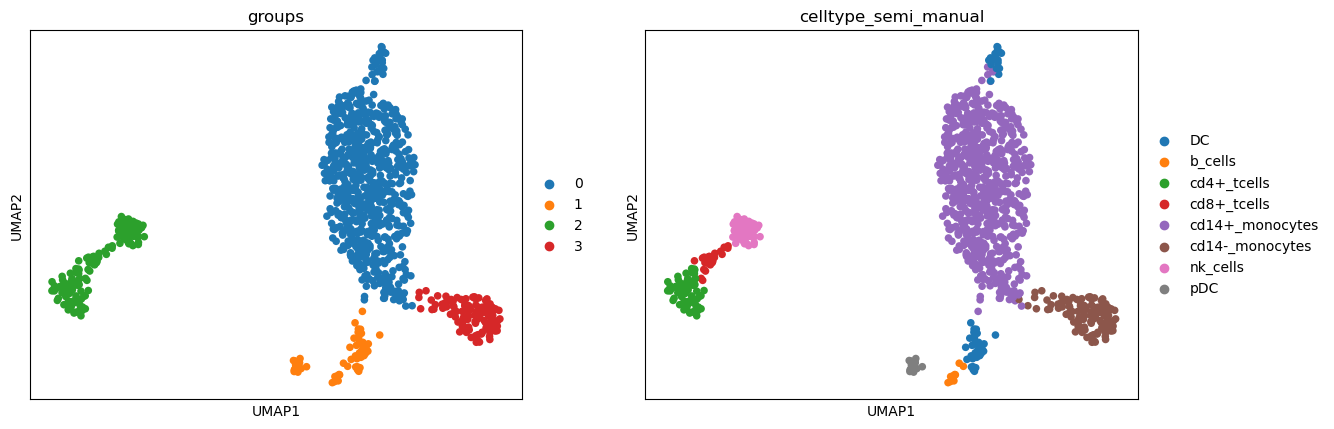

## 6 — Marker Gene Visualization
What is a 'marker gene'?
Visualize known marker genes on the UMAP to help you identify cell types.

> **Hints:**  
> You can find markers for the cell types in this tutorial here: https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html
> See: https://www.sc-best-practices.org/cellular_structure/annotation.html
> 

In [32]:
## E.g. monocytes
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
}

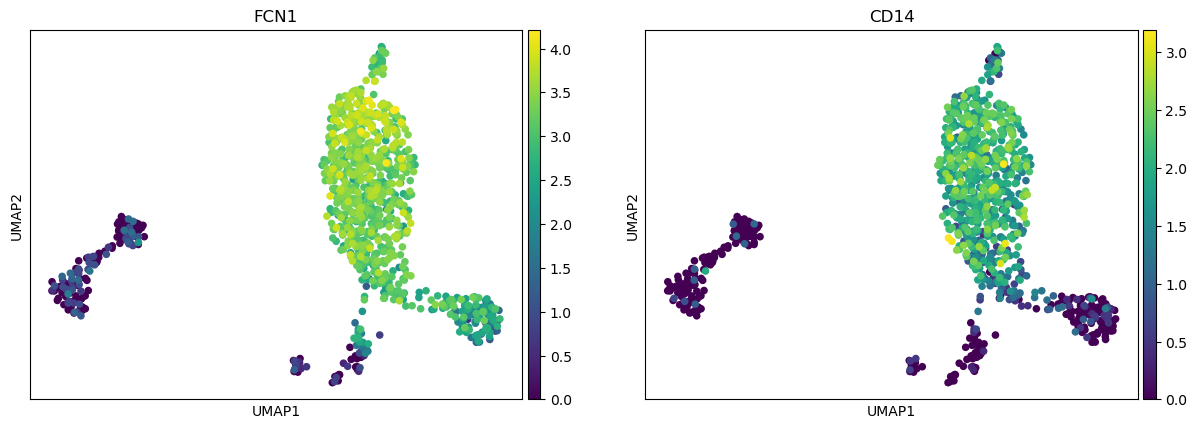

## 7 — Manual Cell Type Annotation

Based on your marker gene exploration, assign a cell type label to each Leiden cluster.

Store your labels in a new column called **`manual_celltype_labels`** in `adata.obs`.

> **Hint:** Map cluster IDs to cell type strings using a dictionary and `adata.obs['leiden'].map({...})`.

Visualize the annotated UMAP with `sc.pl.umap(adata, color='manual_celltype_labels')`.

In [46]:
celltype_map = {'1': 'DC', '0': 'CD14+ Mono', '2': 'T cells', '3': 'CD14-'}
adata.obs['manual_celltype_labels'] = adata.obs['groups'].map(celltype_map)

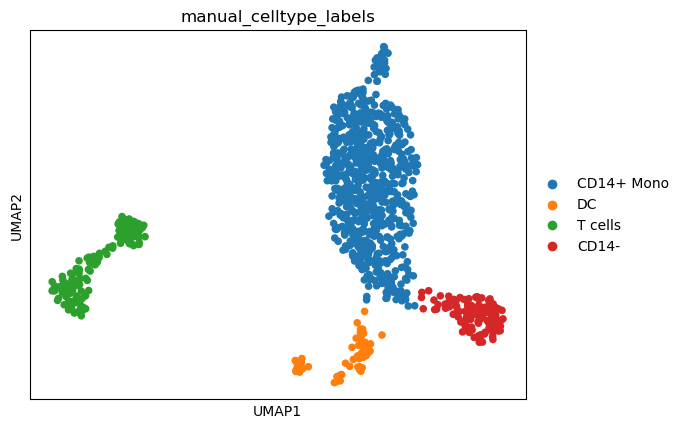

## 8 — Differential Expression

Perform a differential expression test to identify marker genes for each cell type (or a comparison of interest).
Save the file as with the name 'de_genes.tsv' in a tab separated format.

> **Hints:**  

> See: https://www.sc-best-practices.org/conditions/differential_gene_expression.html

Save your DE results as a CSV file (e.g., `de_results.csv`).

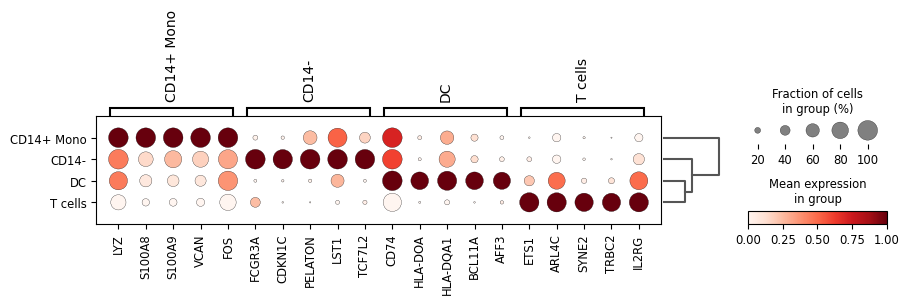

## 9 — Save Results

Make a folder results in your repository. (Programmatically)

Export your results for submission:

1. **`obs.tsv`** — `adata.obs` with `manual_celltype_labels` as a pandas dataframe (you can subset and avoid all the other generated variable)
   Use '\t' as a separator if you want to be able to look at your file conveniently from the command line.

2. **`<your_filename>_qc.h5ad`** — the processed AnnData object.  
  
   ⚠️ This file is excluded by `.gitignore` — do **not** try to commit it.

> **Note:** Only commit `obs.tsv` and your DE results CSV.

In [55]:
import os
import os.path as op
# Set a good results dir
results_dir = 'intro-scrna-seq/results'
os.makedirs(results_dir, exist_ok = True)

## 10 -- HINTS and functions to use.
At the end of the tutorial you should have used the functions shown below in the correct order.

> **Hints:**  
> - `sc.pp.log1p()` — log-transform the data
> - `sc.get.rank_genes_groups_df()` — export results as a DataFrame  
> - Save the raw (normalized but un-scaled) counts with `adata.raw = adata` before scaling
> - `sc.pl.dotplot()` or `sc.pl.violin()` — show expression across clusters
> - `sc.pp.filter_cells()` — filter by minimum/maximum counts or genes  
> - `sc.pp.scale()` — zero-mean, unit-variance scaling (optional but common before PCA)
> - `sc.tl.rank_genes_groups(adata, groupby='manual_celltype_labels', method='wilcoxon')` — Wilcoxon rank-sum test  
> - `sc.pl.rank_genes_groups()` — visualize top DE genes  
> - `sc.pp.filter_genes()` — filter by minimum number of cells
> - `sc.pp.highly_variable_genes()` — find genes that vary across cells  

> - `sc.pp.pca()` — principal component analysis (use `use_highly_variable=True`)  
> - `sc.pp.neighbors()` — construct the *k*-nearest-neighbor graph  
> - `sc.tl.umap()` — compute the UMAP embedding  
> - `sc.tl.leiden()` — Leiden community detection (pass a `resolution` parameter to tune granularity)
> - `sc.pp.normalize_total()` — normalize each cell to a target sum (typically 10 000)  

> - Use `sc.pp.calculate_qc_metrics()`.
> - `sc.pl.umap(adata, color=[...])` — color UMAP by gene expression  
> - `sc.tl.rank_genes_groups()` with `sc.pl.rank_genes_groups()`
> -  Use `adata.write_h5ad('<your_filename>_qc.h5ad')`.
> -  adata.obs.to_csv('obs.tsv', sep='\t')`.

## 11 -- Self control
You can self control by running the following code from the command line
This will be a rudimentary test which checks if the files have been created